<a href="https://colab.research.google.com/github/ShubhamP1028/Spiking-Neural-Networks/blob/main/FirstSNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spiking Neiral Network

Spiking Neural Networks (SNNs), known as third-generation neural networks, mimic biological neurons by using discrete spikes over time rather than continuous activations, enabling energy-efficient processing of temporal data.

They excel in dynamic tasks like speech recognition due to their time-based dynamics and sparsity.

SNNs employ models like Leaky Integrate-and-Fire (LIF) neurons, where membrane potential U[t] integrates input current and decays:

Training uses surrogate gradients to handle non-differentiable spikes, approximating the Heaviside step's derivative (e.g., arctan) during backpropagation through time (BPTT).

In [2]:
!pip install snntorch torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.0 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import snntorch as snn
from snntorch import surrogate, utils
import matplotlib.pyplot as plt

Loading Dataset

using static Dataset MNIST for simplicity

In [13]:
batch_size = 128
num_steps = 25  # simulation steps
data_path = '/tmp/data/mnist'
transform = transforms.Compose([transforms.Resize((28,28)), transforms.Grayscale(), transforms.ToTensor(), transforms.Normalize((0,), (1,))])
train_data = datasets.MNIST(data_path, train=True, download=True, transform=transform)
test_data = datasets.MNIST(data_path, train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)

defining SNN's integrate and fire neuron's constants

In [5]:
num_inputs = 28*28
num_hidden = 1000
num_outputs = 10
beta = 0.95  # decay rate

defining fully connected network for classification with surrogate gradient (fast sigmoid)


this will loops over time steps, simulating recurrences, spikes are rate-coded for accuracy (highest spike count = predicted class).

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []  # record output spikes
        mem2_rec = [] # record output membrane potentials
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

* The Synaptic Layers (nn.Linear)
In neuromorphic terms, these are the synapses.

Role: They carry signals from one neuron to the next.

Action: They multiply the input (spikes or raw data) by a weight.

Result: The output of fc1 and fc2 is treated as electrical current. It doesn't cause a "firing" yet; it just tells the next layer how much "push" it is receiving.

*  The Neuron Layers (snn.Leaky)
This is the LIF (Leaky Integrate-and-Fire) Neuron model. It has three distinct behaviors:

Integrate: It adds the incoming current from the fc layer to its internal "battery" (the Membrane Potential).

Leaky: If no current comes in, the "battery" slowly loses charge (controlled by beta). This prevents the neuron from firing due to old, irrelevant data.

Fire: If the charge exceeds a specific threshold (usually 1.0), the neuron outputs a 1 (a spike) and immediately resets its internal charge to zero.

* The Surrogate Gradient (spike_grad)
This is a mathematical trick for training.

The Problem: Standard AI uses calculus to learn, but a spike is a "jump" from 0 to 1, which is mathematically "flat" or "broken" (zero gradient).

The Fix: During the backward pass (learning), the Fast Sigmoid pretends the spike was a smooth curve. This allows PyTorch to calculate how to adjust the
weights.

*  The Temporal Loop (for step in range)
This is the most important part of SNN logic.

Statefulness: Notice mem1 and mem2 are passed back into the functions every loop. The neuron remembers what happened in the previous microsecond.

The Accumulation: A single input might not be strong enough to make lif1 spike. But if you feed that same input for 5 steps, the charge builds up until—pop—it finally fires.

* The Recording (spk2_rec and mem2_rec)
Since the network runs for many time steps, it produces many outputs.

spk2_rec: A log of every time the final layer fired. If you are classifying digits (0-9), you might look at which of the 10 output neurons fired the most times across all steps.

mem2_rec: A log of the internal voltage. This is often used for debugging or specialized loss functions.


In [7]:
net = Net().cuda() if torch.cuda.is_available() else Net()

Training Loop

Use cross-entropy on membrane potentials (proxy for spikes) and Adam optimizer.

In [8]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()

In [9]:
# Single batch test (fixed)
data, targets = next(iter(train_loader))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
targets = targets.to(device)

utils.reset(net)
spk_rec, mem_rec = net(data.view(batch_size, -1))

loss_val = torch.zeros(1, device=device)
for step in range(num_steps):
    loss_val += loss_fn(spk_rec[step], targets) / num_steps

print(f"Initial loss: {loss_val.item():.3f}")

Initial loss: 2.306


In [10]:
test_batch = next(iter(train_loader))
print(f"Batch type: {type(test_batch)}, length: {len(test_batch)}")
print(f"Data shape: {test_batch[0].shape if len(test_batch) > 0 else 'None'}")
print(f"Targets shape: {test_batch[1].shape if len(test_batch) > 1 else 'None'}")

if len(test_batch) == 2:
    data, targets = test_batch
else:
    print("Unexpected batch format—check your DataLoader or dataset.")
    # Skip for now or adjust based on print output


Batch type: <class 'list'>, length: 2
Data shape: torch.Size([128, 1, 28, 28])
Targets shape: torch.Size([128])


In [11]:
# Training (5 epoch example)
for epoch in range(5):  # Increase for better results
    for data, targets in train_loader:
        data = data.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        spk_rec, mem_rec = net(data.view(batch_size, -1))
        loss_val = torch.zeros(1, device=device)
        for step in range(num_steps):
            loss_val += loss_fn(mem_rec[step], targets) / num_steps  # Use mem for loss
        loss_val.backward()
        optimizer.step()
print("Training complete!")

Training complete!


In [14]:
for epoch in range(5):  # Train multiple epochs
    total_loss = 0
    num_batches = 0
    for data, targets in train_loader:
        data = data.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        spk_rec, mem_rec = net(data.view(batch_size, -1))
        loss_val = torch.zeros(1, device=device)
        for step in range(num_steps):
            loss_val += loss_fn(mem_rec[step], targets) / num_steps  # Use mem_rec for better training
        loss_val.backward()
        optimizer.step()
        total_loss += loss_val.item()
        num_batches += 1
        # Debugging: Check gradients
        if num_batches == 1 and epoch == 0:
            print(f"Gradients for fc1.weight after first batch: {net.fc1.weight.grad.norm():.4f}")
    print(f"Epoch {epoch+1}, Avg Loss: {total_loss / num_batches:.3f}")

Gradients for fc1.weight after first batch: 0.9425
Epoch 1, Avg Loss: 0.033
Epoch 2, Avg Loss: 0.032
Epoch 3, Avg Loss: 0.026
Epoch 4, Avg Loss: 0.026
Epoch 5, Avg Loss: 0.024


# Task
Generate a conceptual diagram of the Spiking Neural Network (SNN) architecture, explicitly illustrating the input, `fc1`, `lif1`, `fc2`, `lif2`, and output layers, and detailing the data flow and recurrent connections. Complement this visual representation with a comprehensive textual explanation of the SNN's operation, covering the role of `num_steps`, the integration of membrane potential (`mem1`, `mem2`), the mechanism of spike generation (`spk1`, `spk2`) by Leaky Integrate-and-Fire (LIF) neurons, the impact of the `beta` decay rate, and the importance of `surrogate.fast_sigmoid()` for gradient estimation. Finally, synthesize these elements into a summary that highlights the critical architectural and functional aspects of the SNN.

## Visualize SNN Architecture

### Subtask:
Generate a conceptual diagram of the SNN architecture using `matplotlib`. This diagram will represent the input, `fc1`, `lif1`, `fc2`, `lif2`, and output layers, showing the flow of data and highlighting the recurrent nature of the SNN.


**Reasoning**:
The subtask requires generating a conceptual diagram of the SNN architecture using `matplotlib`. I will write a Python code block to create the diagram, including layers, data flow arrows, recurrence indications, and relevant annotations, following the detailed instructions.



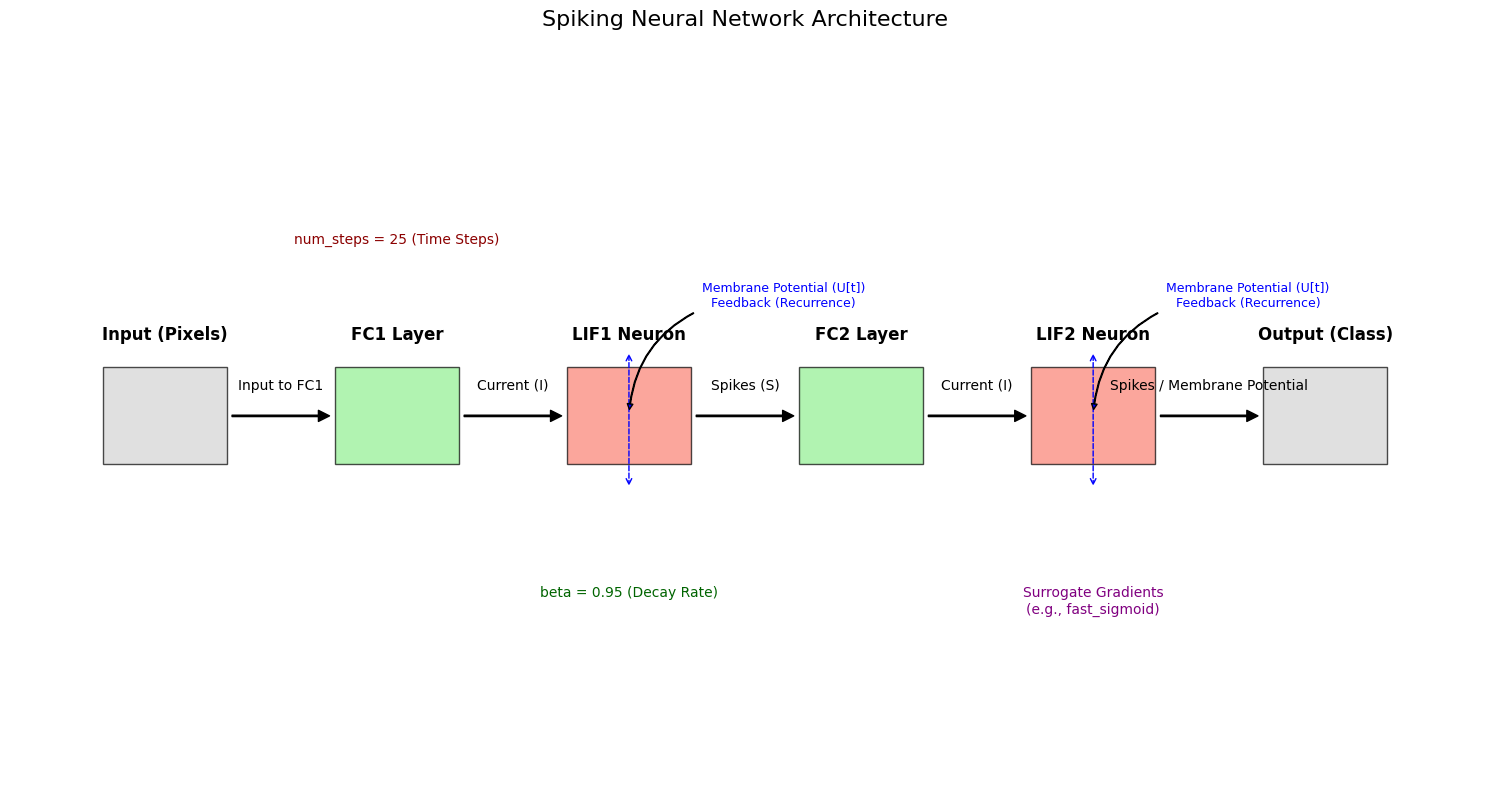

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create figure and axes
fig, ax = plt.subplots(figsize=(15, 8))

# Define layer properties (x, y, width, height)
layer_properties = {
    'Input': {'pos': (0.5, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)},
    'FC1': {'pos': (2.0, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)},
    'LIF1': {'pos': (3.5, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)},
    'FC2': {'pos': (5.0, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)},
    'LIF2': {'pos': (6.5, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)},
    'Output': {'pos': (8.0, 0.5), 'dim': (0.8, 0.4), 'label_offset': (0, -0.2)}
}

def draw_layer(ax, name, props, color='lightblue'):
    x, y = props['pos']
    w, h = props['dim']
    rect = patches.Rectangle((x - w/2, y - h/2), w, h, linewidth=1, edgecolor='black', facecolor=color, alpha=0.7)
    ax.add_patch(rect)
    ax.text(x, y + h/2 + 0.1, name, ha='center', va='bottom', fontsize=12, fontweight='bold')
    return x, y, w, h

# Draw layers
input_x, input_y, input_w, input_h = draw_layer(ax, 'Input (Pixels)', layer_properties['Input'], 'lightgray')
fc1_x, fc1_y, fc1_w, fc1_h = draw_layer(ax, 'FC1 Layer', layer_properties['FC1'], 'lightgreen')
lif1_x, lif1_y, lif1_w, lif1_h = draw_layer(ax, 'LIF1 Neuron', layer_properties['LIF1'], 'salmon')
fc2_x, fc2_y, fc2_w, fc2_h = draw_layer(ax, 'FC2 Layer', layer_properties['FC2'], 'lightgreen')
lif2_x, lif2_y, lif2_w, lif2_h = draw_layer(ax, 'LIF2 Neuron', layer_properties['LIF2'], 'salmon')
output_x, output_y, output_w, output_h = draw_layer(ax, 'Output (Class)', layer_properties['Output'], 'lightgray')

# Draw data flow arrows
arrows = [
    ((input_x + input_w/2, input_y), (fc1_x - fc1_w/2, fc1_y), 'Input to FC1'),
    ((fc1_x + fc1_w/2, fc1_y), (lif1_x - lif1_w/2, lif1_y), 'Current (I)'),
    ((lif1_x + lif1_w/2, lif1_y), (fc2_x - fc2_w/2, fc2_y), 'Spikes (S)'),
    ((fc2_x + fc2_w/2, fc2_y), (lif2_x - lif2_w/2, lif2_y), 'Current (I)'),
    ((lif2_x + lif2_w/2, lif2_y), (output_x - output_w/2, output_y), 'Spikes / Membrane Potential')
]

for start_coords, end_coords, text in arrows:
    ax.annotate('', xy=end_coords, xytext=start_coords,
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8, headlength=8))
    ax.text((start_coords[0] + end_coords[0]) / 2, (start_coords[1] + end_coords[1]) / 2 + 0.1,
            text, ha='center', va='bottom', fontsize=10)

# Add recurrence for LIF neurons
# LIF1 recurrence
ax.annotate('', xy=(lif1_x, lif1_y - lif1_h/2 - 0.1), xytext=(lif1_x, lif1_y + lif1_h/2 + 0.1),
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<->', linestyle='--', linewidth=1),
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="orange", lw=1, alpha=0.5))
ax.annotate('Membrane Potential (U[t])\nFeedback (Recurrence)', xy=(lif1_x, lif1_y), xytext=(lif1_x + 1, lif1_y + 0.5),
            arrowprops=dict(facecolor='blue', shrink=0.05, width=0.5, headwidth=4, headlength=4, connectionstyle="arc3,rad=0.3"),
            ha='center', va='center', fontsize=9, color='blue')

# LIF2 recurrence
ax.annotate('', xy=(lif2_x, lif2_y - lif2_h/2 - 0.1), xytext=(lif2_x, lif2_y + lif2_h/2 + 0.1),
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<->', linestyle='--', linewidth=1),
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="orange", lw=1, alpha=0.5))
ax.annotate('Membrane Potential (U[t])\nFeedback (Recurrence)', xy=(lif2_x, lif2_y), xytext=(lif2_x + 1, lif2_y + 0.5),
            arrowprops=dict(facecolor='blue', shrink=0.05, width=0.5, headwidth=4, headlength=4, connectionstyle="arc3,rad=0.3"),
            ha='center', va='center', fontsize=9, color='blue')

# Add additional text annotations for key concepts
ax.text(fc1_x, fc1_y + 0.7, f'num_steps = {num_steps} (Time Steps)', ha='center', va='bottom', fontsize=10, color='darkred')
ax.text(lif1_x, lif1_y - 0.7, f'beta = {beta} (Decay Rate)', ha='center', va='top', fontsize=10, color='darkgreen')
ax.text(lif2_x, lif2_y - 0.7, 'Surrogate Gradients\n(e.g., fast_sigmoid)', ha='center', va='top', fontsize=10, color='purple')

# Set axis limits and remove ticks
ax.set_xlim(-0.5, 9.0)
ax.set_ylim(-1.0, 2.0)
ax.axis('off')

# Add title
ax.set_title('Spiking Neural Network Architecture', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

#### Explanation of Working of Network layer by layer


1- The Initialization (__init__)
    nn.Linear(num_inputs, num_hidden): This is a standard fully connected layer that calculates "synaptic current" by multiplying input spikes by weights.
    snn.Leaky(...): This is the LIF (Leaky Integrate-and-Fire) neuron.
    beta: The decay rate of the membrane potential (how fast the neuron "forgets" charge).
    spike_grad: Since spikes are non-differentiable (0 or 1), this uses a Surrogate Gradient (Fast Sigmoid) so you can train the network using standard backpropagation.

2- The Processing Logic (forward)

    init_leaky(): This creates the "memory" (membrane potential) for the neurons, starting them at zero.

    for step in range(num_steps): This is the temporal loop. SNNs need to see the input repeatedly over time to decide when to trigger a spike.

    cur1 = self.fc1(x): The input x is converted into a current through the first set of weights.

    spk1, mem1 = self.lif1(cur1, mem1):
    The current cur1 is added to the previous membrane potential mem1.
    If the potential hits a threshold, the neuron emits a spike (spk1 = 1).
    If it spikes, the potential resets; if not, it leaks (decays) based on beta.

    cur2 = self.fc2(spk1): The spikes from the first layer become the input current for the second layer.

    spk2_rec / mem2_rec: These lists "record" every spike and potential over the entire time duration so you can calculate loss at the end.


### SNN Architecture and Operational Explanation

#### Data Flow and Layer Interactions:

1.  **Input Layer**: The raw data (e.g., MNIST images) is flattened and fed into the network. In our example, this is the `Input (Pixels)` layer.

2.  **FC1 Layer (`fc1`)**: This is the first fully connected layer, which transforms the input signal into a current. For each time step `t`, `cur1 = self.fc1(x)` computes the input current to the first LIF neuron layer. It's a standard dense layer that learns weights to process the input features.

3.  **LIF1 Neuron Layer (`lif1`)**: This layer consists of Leaky Integrate-and-Fire (LIF) neurons. It receives current (`cur1`) from `fc1`. The `lif1` neuron integrates this current into its membrane potential (`mem1`) over time. If `mem1` exceeds a threshold, the neuron fires a spike (`spk1`). After firing, `mem1` is reset, and it continuously decays over time at a rate determined by `beta` (`mem1 = self.lif1(cur1, mem1)`). This layer introduces temporal dynamics and sparsity to the network.

4.  **FC2 Layer (`fc2`)**: This is the second fully connected layer. It receives the spikes (`spk1`) generated by the `lif1` layer. `cur2 = self.fc2(spk1)` converts these spikes into a new current that feeds into the second LIF neuron layer.

5.  **LIF2 Neuron Layer (`lif2`)**: Similar to `lif1`, this layer consists of LIF neurons that integrate the current `cur2` into their membrane potential (`mem2`). If `mem2` crosses a threshold, it generates output spikes (`spk2`). `mem2` also decays with `beta` and resets upon spiking. The output spikes and membrane potentials from this layer (`spk2_rec`, `mem2_rec`) are collected across `num_steps` to form the network's output.

6.  **Output Layer**: The collected spikes or membrane potentials from `lif2` over time are used to determine the network's final output, typically by summing spikes or averaging membrane potentials to classify the input.

#### Key Operational Aspects:

*   **`num_steps` (Simulation Steps)**: This parameter defines the duration of the SNN simulation in discrete time steps. The network processes input and propagates spikes iteratively for `num_steps` times. Each `step` in the `for step in range(num_steps)` loop represents a single unit of time during which neurons integrate input, potentially fire, and update their internal state. This temporal dimension is crucial for SNNs to process dynamic or time-series data.

*   **Membrane Potential (`mem1`, `mem2`)**: These variables represent the internal state of the LIF neurons. They integrate incoming currents and, over time, can accumulate charge. When the membrane potential reaches a certain threshold, the neuron generates a spike. `mem.init_leaky()` initializes the membrane potential, and `mem = self.lif(current, mem)` updates it at each time step.

*   **Spike Generation (`spk1`, `spk2`)**: Spikes are binary events (0 or 1) that occur when a neuron's membrane potential crosses its firing threshold. `spk, mem = self.lif(current, mem)` simultaneously calculates the spikes and updates the membrane potential. These discrete events are the primary means of information transmission in SNNs, mimicking biological neurons.

*   **`beta` (Decay Rate)**: The `beta` parameter (e.g., 0.95) determines how quickly the membrane potential decays towards its resting state if no input current is received or after a spike. A higher `beta` means slower decay, allowing the neuron to integrate inputs over a longer period, while a lower `beta` leads to faster decay, making the neuron more sensitive to recent inputs. This mechanism is central to the

### Summary of SNN Architecture and Functionality

The Spiking Neural Network (SNN) presented is a feedforward architecture with recurrent elements embedded within its Leaky Integrate-and-Fire (LIF) neuron layers. It processes information over a fixed number of `num_steps` (time steps), making it suitable for temporal data. The network comprises two fully connected (FC) layers (`fc1`, `fc2`) and two LIF neuron layers (`lif1`, `lif2`).

**Architecturally**, data flows sequentially: Input -> `fc1` (current generation) -> `lif1` (spike generation) -> `fc2` (current generation) -> `lif2` (output spike/potential generation) -> Output. The LIF layers are critical, as they introduce the spiking behavior and temporal dynamics.

**Functionally**, `fc1` and `fc2` act as traditional neural network layers, transforming inputs into currents. The core of the SNN lies in the `lif1` and `lif2` layers. Here, neurons integrate incoming `current` into their `membrane potential` (`mem`). This membrane potential `decays` over time at a rate governed by the `beta` parameter, reflecting the leaky nature of biological neurons. When `mem` crosses a threshold, a discrete `spike` (`spk`) is generated, and the membrane potential is reset. This process is repeated for each of the `num_steps`.

The recurrent connection within each LIF neuron (the feedback loop of membrane potential influencing subsequent state) is fundamental to its temporal integration capabilities. Finally, for training, the non-differentiable nature of spike generation is overcome by using `surrogate gradients`, specifically `surrogate.fast_sigmoid()`, which approximates the derivative of the step function, allowing backpropagation through time to optimize the network's parameters.

## Final Task

### Subtask:
Summarize the key aspects of the SNN's architecture and functioning, integrating insights from both the visual diagram and the detailed explanation.


## Summary:

### Q&A
The SNN's architecture is a feedforward design incorporating recurrent elements within its Leaky Integrate-and-Fire (LIF) neuron layers, processing information over a fixed number of `num_steps`. Data flows sequentially from Input to `fc1` (current generation), then to `lif1` (spike generation), followed by `fc2` (current generation), and finally to `lif2` (output spike/potential generation) before reaching the Output.

Functionally, `fc1` and `fc2` transform inputs into currents. The LIF layers (`lif1`, `lif2`) are central, integrating incoming current into `membrane potential` (`mem`), which decays at a rate determined by `beta`. When `mem` exceeds a threshold, a `spike` (`spk`) is generated, and `mem` is reset. This process repeats for each `num_steps`. The recurrent connection within each LIF neuron allows for temporal integration, and `surrogate gradients` (e.g., `surrogate.fast_sigmoid()`) are used to enable backpropagation for training through non-differentiable spike generation.

### Data Analysis Key Findings
*   A conceptual diagram of the SNN architecture was successfully generated, visually representing the `Input`, `fc1`, `lif1`, `fc2`, `lif2`, and `Output` layers.
*   The diagram clearly depicted the sequential data flow between layers using arrows and highlighted recurrent connections within the `LIF1` and `LIF2` layers, indicating membrane potential feedback.
*   Key SNN parameters and concepts, such as `num_steps` (time steps), `beta` (decay rate), and the use of `surrogate.fast_sigmoid()` for gradient estimation, were annotated in the diagram.
*   A comprehensive textual explanation detailed the operational aspects, including the role of `num_steps` in defining simulation duration, the integration of `membrane potential` (`mem1`, `mem2`) from incoming currents, the binary `spike generation` (`spk1`, `spk2`) when potential exceeds a threshold, and the impact of the `beta` decay rate on membrane potential.

### Insights or Next Steps
*   Combining visual diagrams with detailed textual explanations significantly enhances the clarity and understanding of complex system architectures like SNNs.
*   The established framework of representing sequential data flow, recurrent connections, and key operational parameters provides a strong foundation for further analysis or optimization of the SNN's performance.
